# Feature Space Analysis Using Xception

This notebook analyzes the learned feature space of the trained Xception model
for brain tumor MRI classification.

## Objectives

1. Load the best trained Xception model.
2. Create a test data generator using the saved test DataFrame.
3. Extract 2048-dimensional feature vectors from the Global Average Pooling layer.
4. Save extracted features, labels, and image filepaths for reproducibility.
5. Reduce feature dimensionality using Principal Component Analysis (PCA).
6. Visualize class distributions in the feature space using PCA and t-SNE.
7. Analyze the similarity between Glioma feature representations and other classes.

## Notes

- The test generator uses `shuffle=False` to preserve the alignment between
  extracted features, true labels, and image filepaths.
- Feature vectors are extracted from the `GlobalAveragePooling2D` layer,
  which produces a 2048-dimensional representation for each MRI image.
- PCA and t-SNE are applied only to the test-set features.
- No model training is performed in this notebook.


# 1. Import Needed Libraries

In [ ]:
# ----------------------------------
# Import required libraries
# ----------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model

# 2. Path & Labels Configuration

In [ ]:
# ----------------------------------
# Project paths & labels
# ----------------------------------

PROJECT_ROOT = Path("..")

MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
DATAFRAMES_DIR = RESULTS_DIR / "dataframes"
ERROR_ANALYSIS_DIR = RESULTS_DIR / "error_analysis"
tSNE_DIR = ERROR_ANALYSIS_DIR / "t-SNE"

BEST_MODEL_PATH = MODELS_DIR / "xception_baseline.keras"
TEST_DF_PATH = DATAFRAMES_DIR / "test_dataframe.csv"

tSNE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (299, 299)
BATCH_SIZE = 32

# Class names must follow the generator/model class order
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]

# Verify class-to-index mapping
class_to_index = {
    class_name: class_id
    for class_id, class_name in enumerate(class_names)
}

print(class_to_index)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# 3. Load Test DataFrame and Create Test Generator

In [5]:
# ----------------------------------
# Load test dataframe
# ----------------------------------
test_df = pd.read_csv(TEST_DF_PATH)

print(f"Number of test samples: {len(test_df)}")
print("\nColumns:")
print(test_df.columns.tolist())

display(test_df.head())

Number of test samples: 800

Columns:
['filepath', 'label']


,filepath,label
0,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor
1,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
2,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma
3,/home/mehr/.cache/kagglehub/datasets/masoudnic...,notumor
4,/home/mehr/.cache/kagglehub/datasets/masoudnic...,glioma


In [8]:
# ----------------------------------
# Create test generator
# ----------------------------------
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

ts_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
)

labels = list(ts_gen.class_indices.keys())
class_to_index = ts_gen.class_indices
index_to_class = {index: label for label, index in class_to_index.items()}

print("Class indices:", class_to_index)
print("Labels:", labels)

Found 800 validated image filenames belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Labels: ['glioma', 'meningioma', 'notumor', 'pituitary']


# 4. Load the Best Model

In [11]:
# ----------------------------------
# Load trained model
# ----------------------------------
model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("Model loaded successfully.")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


I0000 00:00:1787772254.367778   44719 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3600 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model loaded successfully.
Model input shape: (None, 299, 299, 3)
Model output shape: (None, 4)


# 3. Preparing Labels for Model Evaluation

In [13]:
# ----------------------------------
# Generate predictions on the test set
# ----------------------------------
ts_gen.reset()

y_prob = model.predict(ts_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.array(ts_gen.classes)

confidence = np.max(y_prob, axis=1)

print("Prediction probabilities shape:", y_prob.shape)
print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step
Prediction probabilities shape: (800, 4)
True labels shape: (800,)
Predicted labels shape: (800,)


In [ ]:
# ----------------------------------
# Extract 2048-dimensional features
# ----------------------------------

base_model = model.layers[0]

feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print(feature_extractor.output_shape)


ts_gen.reset()

features = feature_extractor.predict(
    ts_gen,
    verbose=1
)

print("Feature shape:", features.shape)


(None, 2048)


I0000 00:00:1787773555.637794   49992 service.cc:148] XLA service 0x72bb0409ad00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787773555.637863   49992 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-08-26 23:15:55.724126: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-26 23:16:24.966569: W external/local_xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.3 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
I0000 00:00:1787773585.652644   49992 device_compiler.h:188] Compiled cluster using XLA! 

25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 224ms/step
Feature shape: (800, 2048)


# 4. Feature-Space Analysis: PCA and t-SNE

In [ ]:
# ----------------------------------
# Reduce feature dimensions using PCA and t-SNE
# ----------------------------------

scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

# PCA: reduce 2048-dimensional features to 50 dimensions
pca = PCA(
    n_components=50,
    random_state=42,
)

features_pca = pca.fit_transform(features_scaled)

print("PCA shape:", features_pca.shape)
print(
    f"Explained variance by 50 PCA components: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

# t-SNE: reduce PCA features to two dimensions for visualization
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
)

features_tsne = tsne.fit_transform(features_pca)

print("t-SNE shape:", features_tsne.shape)


PCA shape: (800, 50)
Explained variance by 50 PCA components: 67.28%
t-SNE shape: (800, 2)


# 5. t-SNE based on true classes

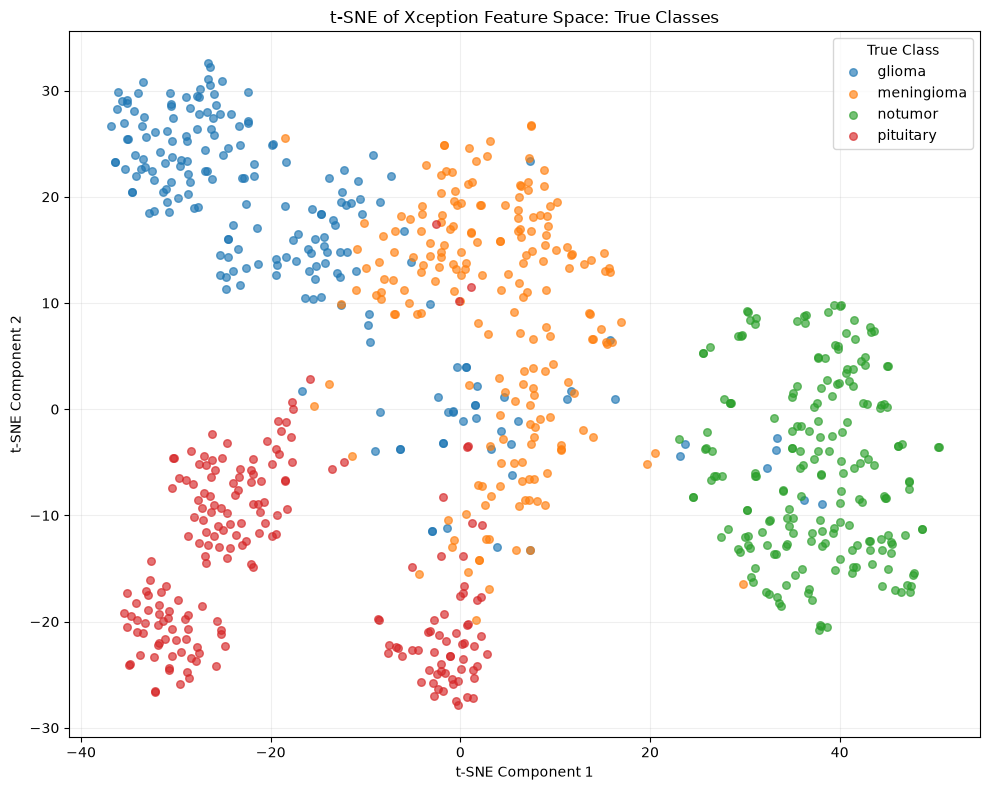

In [ ]:
# ----------------------------------
# Visualize true classes in t-SNE feature space
# ----------------------------------

plt.figure(figsize=(10, 8))

for class_id, class_name in enumerate(class_names):
    idx = y_true == class_id

    plt.scatter(
        features_tsne[idx, 0],
        features_tsne[idx, 1],
        label=class_name,
        alpha=0.65,
        s=30,
    )

plt.title("t-SNE of Xception Feature Space: True Classes")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="True Class")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    tSNE_DIR / "tsne_true_classes.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# 6. t-SNE based on predicted classes

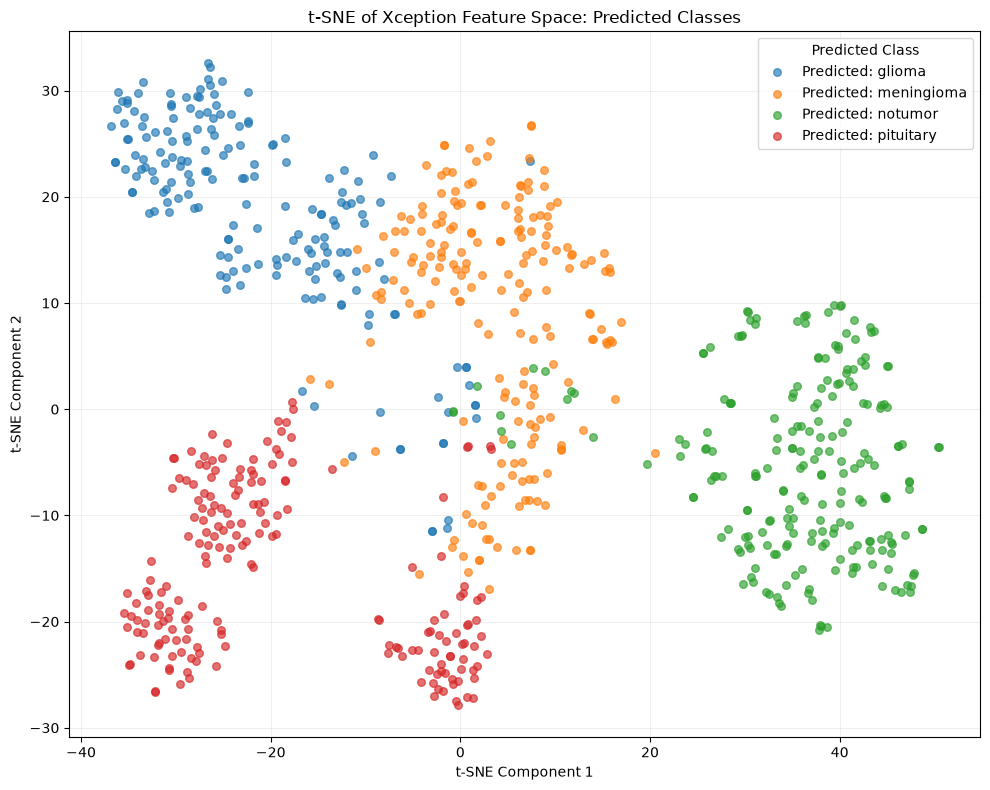

In [ ]:
# ----------------------------------
# Visualize predicted classes in t-SNE feature space
# ----------------------------------

plt.figure(figsize=(10, 8))

for class_id, class_name in enumerate(class_names):
    idx = y_pred == class_id

    plt.scatter(
        features_tsne[idx, 0],
        features_tsne[idx, 1],
        label=f"Predicted: {class_name}",
        alpha=0.65,
        s=30,
    )

plt.title("t-SNE of Xception Feature Space: Predicted Classes")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Predicted Class")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    tSNE_DIR / "tsne_predicted_classes.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# 7. Glioma error analysis in t-SNE space

In [ ]:
# ----------------------------------
# Define class identifiers for Glioma error analysis
# ----------------------------------

GLIOMA_ID = class_to_index["glioma"]
MENINGIOMA_ID = class_to_index["meningioma"]
NOTUMOR_ID = class_to_index["notumor"]

# All actual Glioma samples
idx_glioma = y_true == GLIOMA_ID

# Glioma samples predicted as Meningioma
idx_glioma_to_meningioma = (
    (y_true == GLIOMA_ID)
    & (y_pred == MENINGIOMA_ID)
)

# Glioma samples predicted as No Tumor
idx_glioma_to_notumor = (
    (y_true == GLIOMA_ID)
    & (y_pred == NOTUMOR_ID)
)

print("True Glioma samples:", idx_glioma.sum())
print("Glioma → Meningioma errors:", idx_glioma_to_meningioma.sum())
print("Glioma → No Tumor errors:", idx_glioma_to_notumor.sum())


True Glioma samples: 200
Glioma → Meningioma errors: 13
Glioma → No Tumor errors: 14


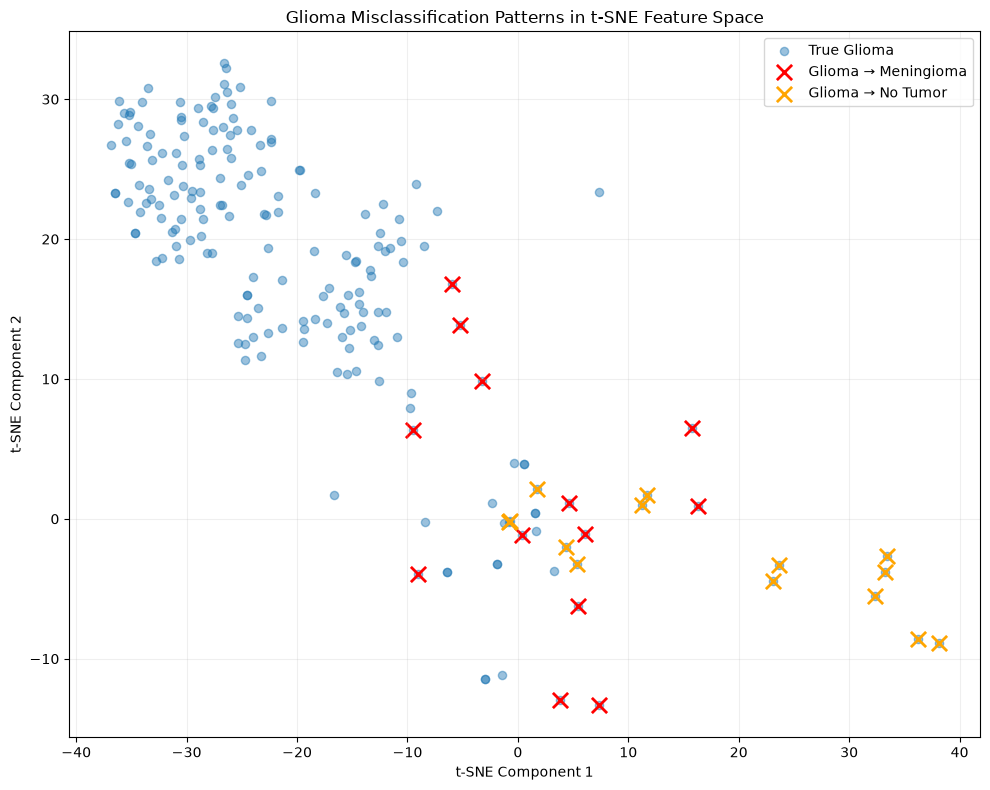

In [ ]:
# ----------------------------------
# Visualize Glioma errors among all true Glioma samples
# ----------------------------------

plt.figure(figsize=(10, 8))

# Display all true Glioma samples in the background
plt.scatter(
    features_tsne[idx_glioma, 0],
    features_tsne[idx_glioma, 1],
    alpha=0.45,
    s=35,
    color="tab:blue",
    label="True Glioma",
)

# Highlight Glioma → Meningioma errors
plt.scatter(
    features_tsne[idx_glioma_to_meningioma, 0],
    features_tsne[idx_glioma_to_meningioma, 1],
    marker="x",
    s=120,
    linewidths=2,
    color="red",
    label="Glioma → Meningioma",
)

# Highlight Glioma → No Tumor errors
plt.scatter(
    features_tsne[idx_glioma_to_notumor, 0],
    features_tsne[idx_glioma_to_notumor, 1],
    marker="x",
    s=120,
    linewidths=2,
    color="orange",
    label="Glioma → No Tumor",
)

plt.title("Glioma Misclassification Patterns in t-SNE Feature Space")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    tSNE_DIR / "tsne_glioma_error_analysis.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


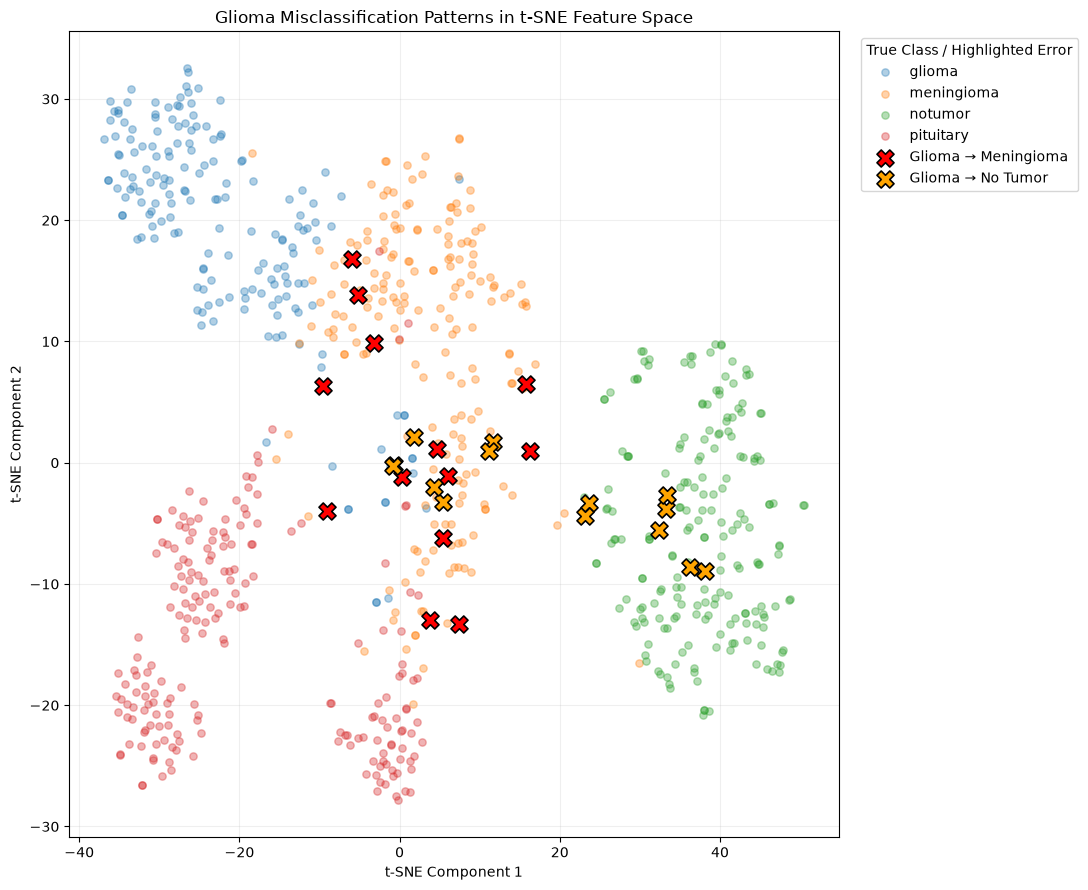

In [28]:
# ----------------------------------
# Visualize Glioma errors among all classes in t-SNE feature space
# ----------------------------------

plt.figure(figsize=(11, 9))

# Display all samples by their TRUE class as background points
for class_id, class_name in enumerate(class_names):
    idx = y_true == class_id

    plt.scatter(
        features_tsne[idx, 0],
        features_tsne[idx, 1],
        label=class_name,
        alpha=0.35,
        s=28,
    )

# Highlight: True Glioma predicted as Meningioma
idx_glioma_to_meningioma = (
    (y_true == GLIOMA_ID)
    & (y_pred == MENINGIOMA_ID)
)

plt.scatter(
    features_tsne[idx_glioma_to_meningioma, 0],
    features_tsne[idx_glioma_to_meningioma, 1],
    marker="X",
    s=150,
    linewidths=1.2,
    edgecolors="black",
    color="red",
    label="Glioma → Meningioma",
    zorder=10,
)

# Highlight: True Glioma predicted as No Tumor
idx_glioma_to_notumor = (
    (y_true == GLIOMA_ID)
    & (y_pred == NOTUMOR_ID)
)

plt.scatter(
    features_tsne[idx_glioma_to_notumor, 0],
    features_tsne[idx_glioma_to_notumor, 1],
    marker="X",
    s=150,
    linewidths=1.2,
    edgecolors="black",
    color="orange",
    label="Glioma → No Tumor",
    zorder=10,
)

plt.title("Glioma Misclassification Patterns in t-SNE Feature Space")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend(
    title="True Class / Highlighted Error",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    tSNE_DIR / "tsne_glioma_error_analysis_all_classes.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# Conclusion

The feature-space analysis shows how the trained Xception model represents
brain MRI images across the four target classes: Glioma, Meningioma,
No Tumor, and Pituitary.

PCA was used to reduce the original 2048-dimensional feature vectors to
50 components while preserving a substantial portion of the total variance.
The t-SNE visualizations provide a two-dimensional view of the learned
feature space and reveal the degree of separation and overlap between classes.

The true-label and predicted-label t-SNE plots help compare the actual
class distribution with the model's decision behavior. In particular,
highlighting Glioma misclassifications makes it possible to inspect whether
incorrectly predicted Glioma samples are positioned near Meningioma or
No Tumor regions in the learned feature space.

If the highlighted misclassified samples are located close to another class
cluster, this suggests that their learned representations partially overlap
with that class. Such overlap may help explain the observed classification
errors and complements the Grad-CAM-based visual error analysis.

This analysis is exploratory. Since t-SNE is a non-linear visualization
method, distances and cluster boundaries in the two-dimensional plot should
not be interpreted as definitive quantitative evidence.
